# Siemens Advanta- Bussines Case Project 2025/2026

**Project developed by Group V**:
   - Alano Gonçalves (20250457)
   - Catarina Martins (20221914)
   - João Carichas (20250507)
   - Marta Ribeiro (20221886)
   - Nicole Nogueira(20221961)

## 1. Import the needed libraries

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from math import ceil
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score   
from sklearn.impute import KNNImputer 
import zipfile
import xml.etree.ElementTree as ET
import matplotlib.ticker as mticker

## 2. Data importation

In [37]:
MARKET_PATH = 'Case2_market_data_share.xlsx'
df_market = pd.read_excel(MARKET_PATH, sheet_name='Sheet1')
df_period_map = pd.read_excel(MARKET_PATH, sheet_name='Sheet2')

In [39]:
df_merged = pd.read_csv('df_merged_1.csv')

## 3. Data exploration and understanding

In [40]:
df_merged.tail()

,Business_Unit,Segment,Subsegment,Period,Biz_Desc,Orders,Revenue,China_Core_Inflation_Rate,China_Exports,China_GDP,...,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production,Date,Start_Period,End_Period
5623,SSI070,SSI07099,SSI07099,38,NaN,0,0,0.6,301.60,18270.36,...,863.2,2314.1,-0.1,0.6,3.3,5.5,6900.0,2024-05-01,15,24
5624,SSI070,SSI07099,SSI07099,39,NaN,0,0,0.6,307.24,18270.36,...,870.0,2368.9,0.8,0.0,3.0,5.5,6700.0,2024-06-01,15,24
5625,SSI070,SSI07099,SSI07099,40,NaN,0,0,0.4,300.22,18270.36,...,870.0,2368.9,-0.9,-0.9,2.9,5.5,6900.0,2024-07-01,15,24
5626,SSI070,SSI07099,SSI07099,41,NaN,0,0,0.3,308.24,18270.36,...,870.0,2368.9,-0.4,0.5,2.5,5.5,7000.0,2024-08-01,15,24
5627,SSI070,SSI07099,SSI07099,42,NaN,0,0,0.1,303.37,18270.36,...,872.5,2389.0,-1.2,-0.6,2.4,5.0,6700.0,2024-09-01,15,24


In [41]:
#overview the dataset
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5628 entries, 0 to 5627
Data columns (total 84 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Business_Unit                             5628 non-null   object 
 1   Segment                                   5628 non-null   object 
 2   Subsegment                                5628 non-null   object 
 3   Period                                    5628 non-null   int64  
 4   Biz_Desc                                  4237 non-null   object 
 5   Orders                                    5628 non-null   int64  
 6   Revenue                                   5628 non-null   int64  
 7   China_Core_Inflation_Rate                 5628 non-null   float64
 8   China_Exports                             5628 non-null   float64
 9   China_GDP                                 5628 non-null   float64
 10  China_GDP_from_Construction         

In [42]:
#checking number of missing values
df_merged.isna().sum()

Business_Unit                                  0
Segment                                        0
Subsegment                                     0
Period                                         0
Biz_Desc                                    1391
Orders                                         0
Revenue                                        0
China_Core_Inflation_Rate                      0
China_Exports                                  0
China_GDP                                      0
China_GDP_from_Construction                    0
China_GDP_from_Manufacturing                   0
China_Industrial_Production                    0
China_Industrial_Production_Mom                0
China_Inflation_Rate                           0
China_Interest_Rate                            0
China_Steel_Production                         0
France_Core_Inflation_Rate                     0
France_Exports                                 0
France_GDP                                     0
France_GDP_from_Cons

In [43]:
#checking missing values after merging 
pd.set_option('display.max_rows', None)
df_merged.isna().sum()/len(df_merged) * 100

Business_Unit                                0.000000
Segment                                      0.000000
Subsegment                                   0.000000
Period                                       0.000000
Biz_Desc                                    24.715707
Orders                                       0.000000
Revenue                                      0.000000
China_Core_Inflation_Rate                    0.000000
China_Exports                                0.000000
China_GDP                                    0.000000
China_GDP_from_Construction                  0.000000
China_GDP_from_Manufacturing                 0.000000
China_Industrial_Production                  0.000000
China_Industrial_Production_Mom              0.000000
China_Inflation_Rate                         0.000000
China_Interest_Rate                          0.000000
China_Steel_Production                       0.000000
France_Core_Inflation_Rate                   0.000000
France_Exports              

In [44]:
df_merged[df_merged['Subsegment'] == 'SSI0278006']

,Business_Unit,Segment,Subsegment,Period,Biz_Desc,Orders,Revenue,China_Core_Inflation_Rate,China_Exports,China_GDP,...,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production,Date,Start_Period,End_Period
336,SSI027,SSI02780,SSI0278006,1,NaN,0,0,0.7,263.09,14996.41,...,892.8,2247.8,16.1,0.1,4.2,0.25,6900.0,2021-04-01,37,42
337,SSI027,SSI02780,SSI0278006,2,NaN,0,0,0.9,263.23,14996.41,...,892.8,2247.8,15.3,0.9,5.0,0.25,7200.0,2021-05-01,37,42
338,SSI027,SSI02780,SSI0278006,3,NaN,0,0,0.9,280.30,14996.41,...,904.4,2275.1,8.7,0.5,5.4,0.25,7100.0,2021-06-01,37,42
339,SSI027,SSI02780,SSI0278006,4,NaN,0,0,1.3,281.28,14996.41,...,904.4,2275.1,5.3,0.4,5.4,0.25,7500.0,2021-07-01,37,42
340,SSI027,SSI02780,SSI0278006,5,NaN,0,0,1.2,293.17,14996.41,...,904.4,2275.1,4.3,0.0,5.3,0.25,7500.0,2021-08-01,37,42
341,SSI027,SSI02780,SSI0278006,6,NaN,0,0,1.2,304.70,14996.41,...,886.3,2276.0,3.2,-1.0,5.4,0.25,7300.0,2021-09-01,37,42
342,SSI027,SSI02780,SSI0278006,7,NaN,0,0,1.3,299.12,14996.41,...,886.3,2276.0,4.0,1.4,6.2,0.25,7500.0,2021-10-01,37,42
343,SSI027,SSI02780,SSI0278006,8,NaN,0,0,1.2,324.28,14996.41,...,886.3,2276.0,4.5,0.9,6.8,0.25,7200.0,2021-11-01,37,42
344,SSI027,SSI02780,SSI0278006,9,NaN,0,0,1.2,339.66,18201.70,...,866.9,2358.9,3.0,-0.1,7.0,0.25,7200.0,2021-12-01,37,42
345,SSI027,SSI02780,SSI0278006,10,NaN,0,0,1.2,323.28,18201.70,...,866.9,2358.9,2.4,0.0,7.5,0.25,7300.0,2022-01-01,37,42


In [45]:
# count how many distinct subsegments each segment has
subseg_counts = (
    df_merged.groupby('Segment')['Subsegment']
    .nunique()
    .reset_index()
    .rename(columns={'Subsegment': 'Subseg_Count'})
)

df_merged = df_merged.merge(subseg_counts, on='Segment', how='left')

# only flag as direct if segment = subsegment AND it's the only subsegment
df_merged['Is_Direct'] = (
    (df_merged['Segment'] == df_merged['Subsegment']) &
    (df_merged['Subseg_Count'] == 1)
)

print("Direct cases (segment = subsegment, no other subsegments):")
print(df_merged[df_merged['Is_Direct']]['Segment'].unique())
print("Count of direct segments:", df_merged[df_merged['Is_Direct']]['Segment'].nunique())

Direct cases (segment = subsegment, no other subsegments):
['SSI02792' 'SSI02793' 'SSI02796' 'SSI02798' 'SSI02799' 'SSI03784'
 'SSI03798' 'SSI03799' 'SSI04799' 'SSI07098' 'SSI07099']
Count of direct segments: 11


### 3.2. EDA and feature visualization

In [51]:
print("Shape:", df_merged.shape)
print("\nColumns:", df_merged.columns.tolist())
print("\nPeriod range:", df_merged['Period'].min(), "to", df_merged['Period'].max())
print("\nUnique BUs:", df_merged['Business_Unit'].nunique())
print("\nUnique segments:", df_merged['Segment'].nunique())
print("\nUnique subsegments:", df_merged['Subsegment'].nunique())
print("\nMissing values:", df_merged.isna().sum()[df_merged.isna().sum() > 0])
print("\nDirect segments:", df_merged[df_merged['Is_Direct']]['Segment'].nunique())

Shape: (5628, 86)

Columns: ['Business_Unit', 'Segment', 'Subsegment', 'Period', 'Biz_Desc', 'Orders', 'Revenue', 'China_Core_Inflation_Rate', 'China_Exports', 'China_GDP', 'China_GDP_from_Construction', 'China_GDP_from_Manufacturing', 'China_Industrial_Production', 'China_Industrial_Production_Mom', 'China_Inflation_Rate', 'China_Interest_Rate', 'China_Steel_Production', 'France_Core_Inflation_Rate', 'France_Exports', 'France_GDP', 'France_GDP_from_Construction', 'France_GDP_from_Manufacturing', 'France_Industrial_Production', 'France_Industrial_Production_Mom', 'France_Inflation_Rate', 'France_Interest_Rate', 'Germany_Core_Inflation_Rate', 'Germany_Exports', 'Germany_GDP', 'Germany_GDP_from_Construction', 'Germany_GDP_from_Manufacturing', 'Germany_Industrial_Production', 'Germany_Industrial_Production_Mom', 'Germany_Inflation_Rate', 'Germany_Interest_Rate', 'Germany_Steel_Production', 'Italy_Core_Inflation_Rate', 'Italy_Exports', 'Italy_GDP', 'Italy_GDP_from_Construction', 'Italy_GDP

#### 3.2.1. Revenue over time per BUs / Segment

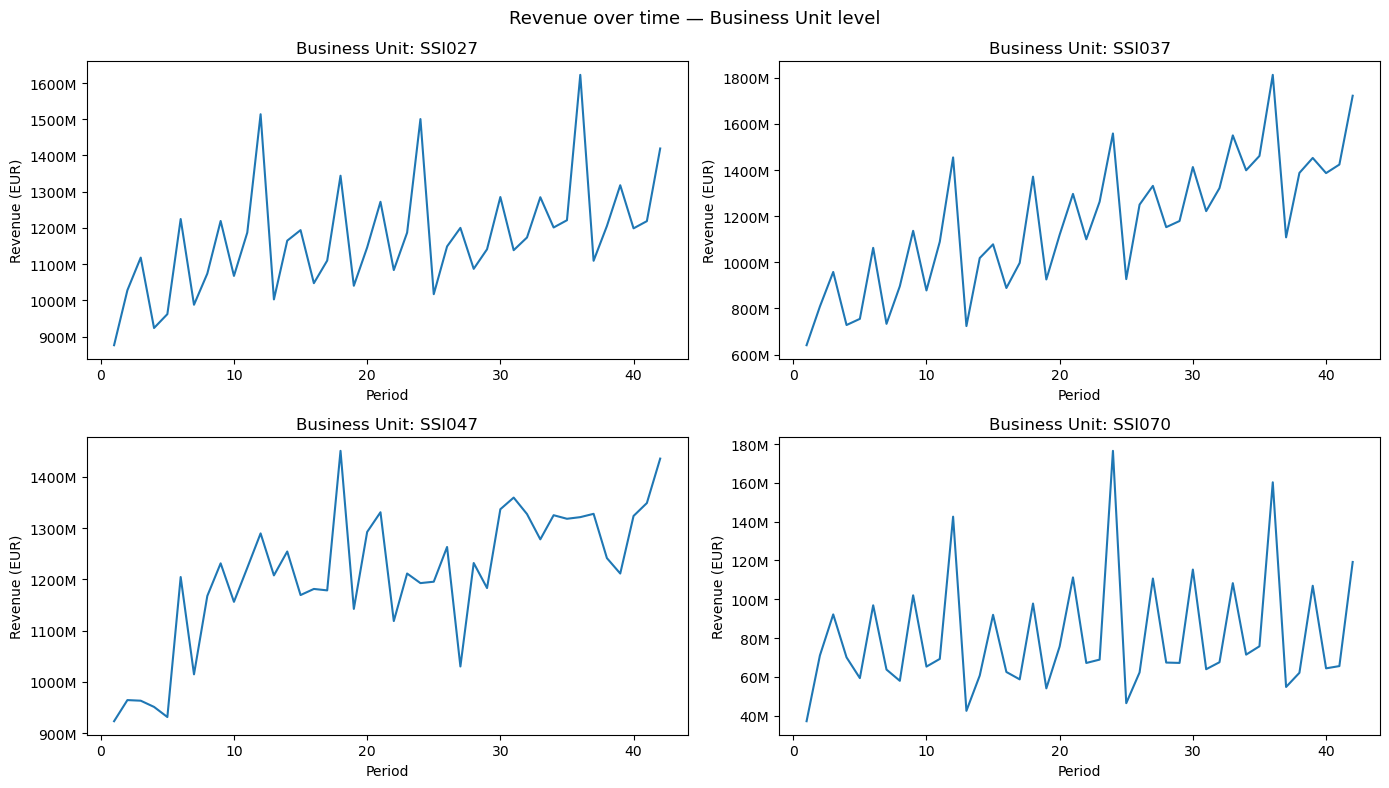

In [ ]:
#revenue over time at BUSINESS UNIT level
bu_data = df_merged.groupby(['Period', 'Business_Unit'])['Revenue'].sum().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, bu in enumerate(sorted(bu_data['Business_Unit'].unique())):
    d = bu_data[bu_data['Business_Unit'] == bu]
    axes[i].plot(d['Period'], d['Revenue'])
    axes[i].set_title(f'Business Unit: {bu}')
    axes[i].set_xlabel('Period')
    axes[i].set_ylabel('Revenue (EUR)')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.suptitle('Revenue over time — Business Unit level', fontsize=13)
plt.tight_layout()
plt.savefig('revenue_business_units.png', dpi=150)
plt.show()

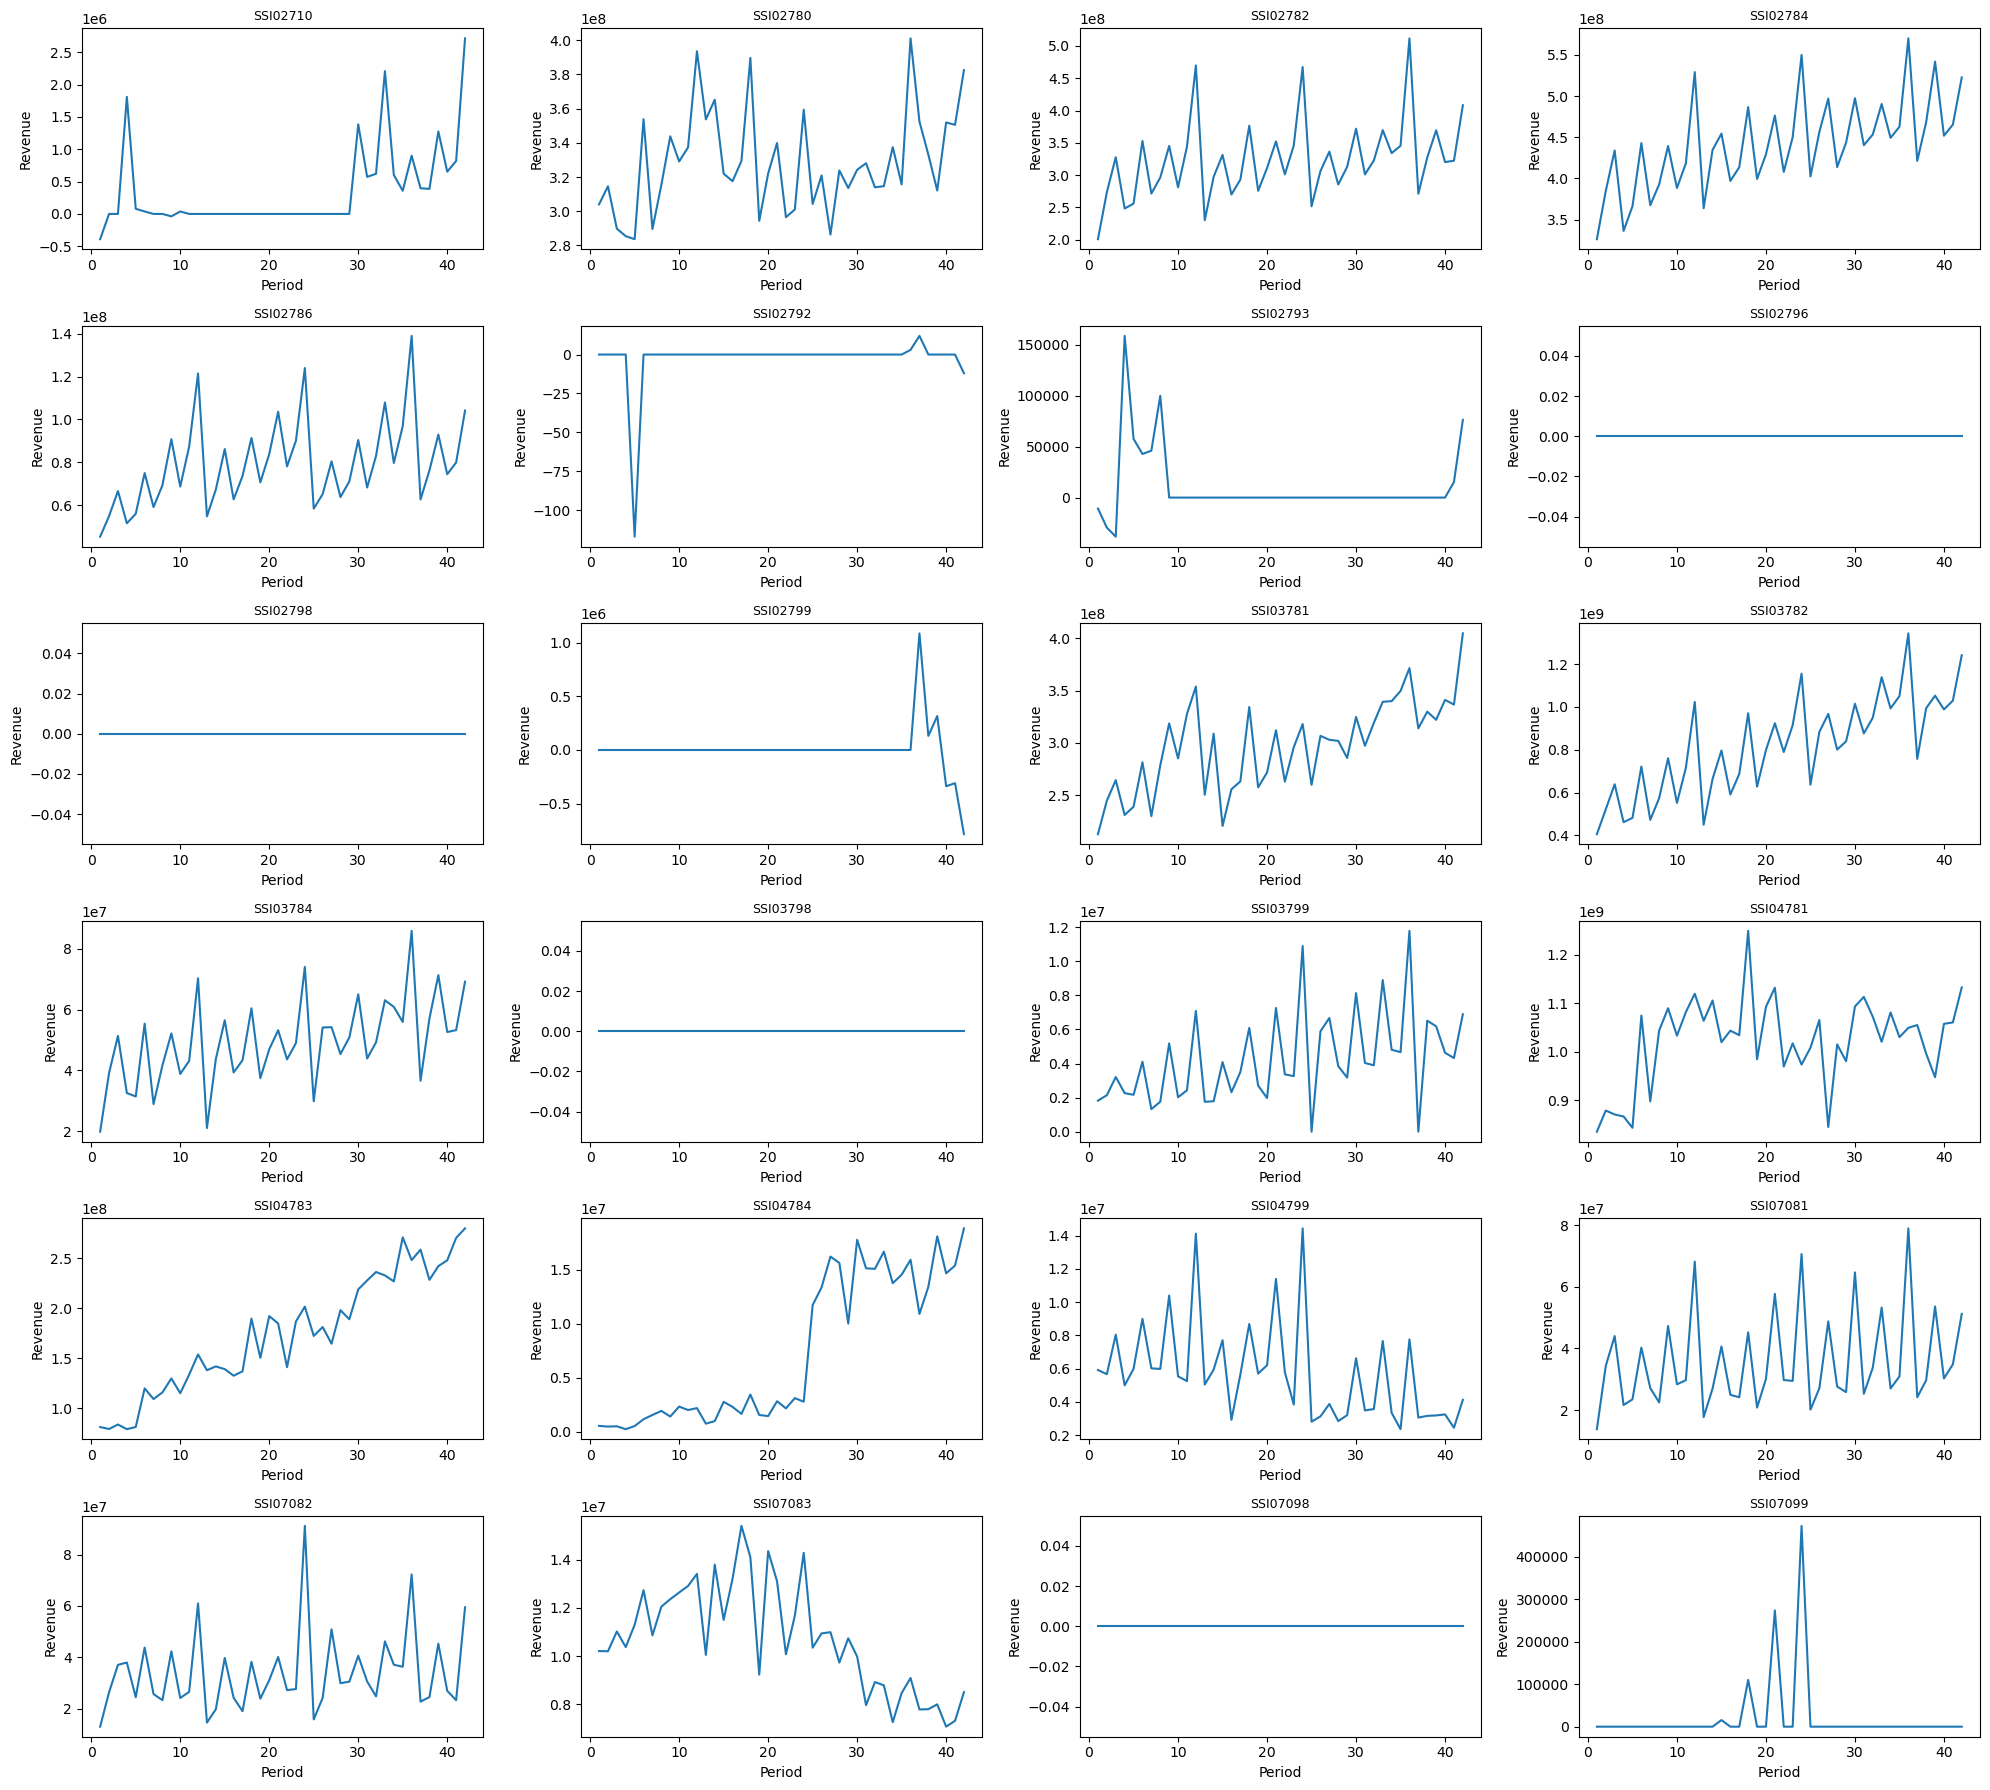

In [ ]:
#revenue over time at SEGMENT level
segments = df_merged['Segment'].unique()

fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20, 18))
axes = axes.flatten()

for i, seg in enumerate(sorted(segments)):
    seg_data = (
        df_merged[df_merged['Segment'] == seg]
        .groupby('Period')['Revenue']
        .sum()
        .reset_index()
    )
    axes[i].plot(seg_data['Period'], seg_data['Revenue'])
    axes[i].set_title(seg, fontsize=9)
    axes[i].set_xlabel('Period')
    axes[i].set_ylabel('Revenue')

plt.tight_layout()
plt.savefig('revenue_per_segment.png', dpi=150)
plt.show()

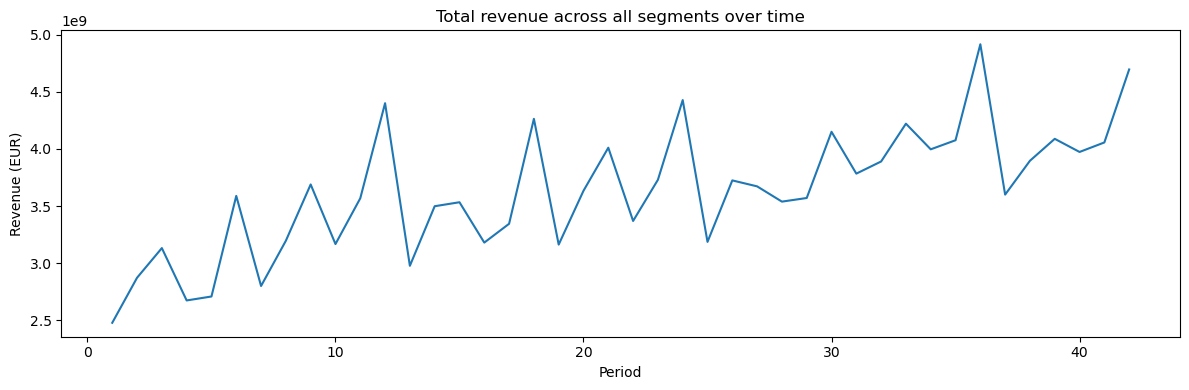

In [49]:
total_revenue = df_merged.groupby('Period')['Revenue'].sum().reset_index()

plt.figure(figsize=(12, 4))
plt.plot(total_revenue['Period'], total_revenue['Revenue'])
plt.title('Total revenue across all segments over time')
plt.xlabel('Period')
plt.ylabel('Revenue (EUR)')
plt.tight_layout()
plt.savefig('total_revenue_trend.png', dpi=150)
plt.show()

#### 3.2.2. Checking Seasonality

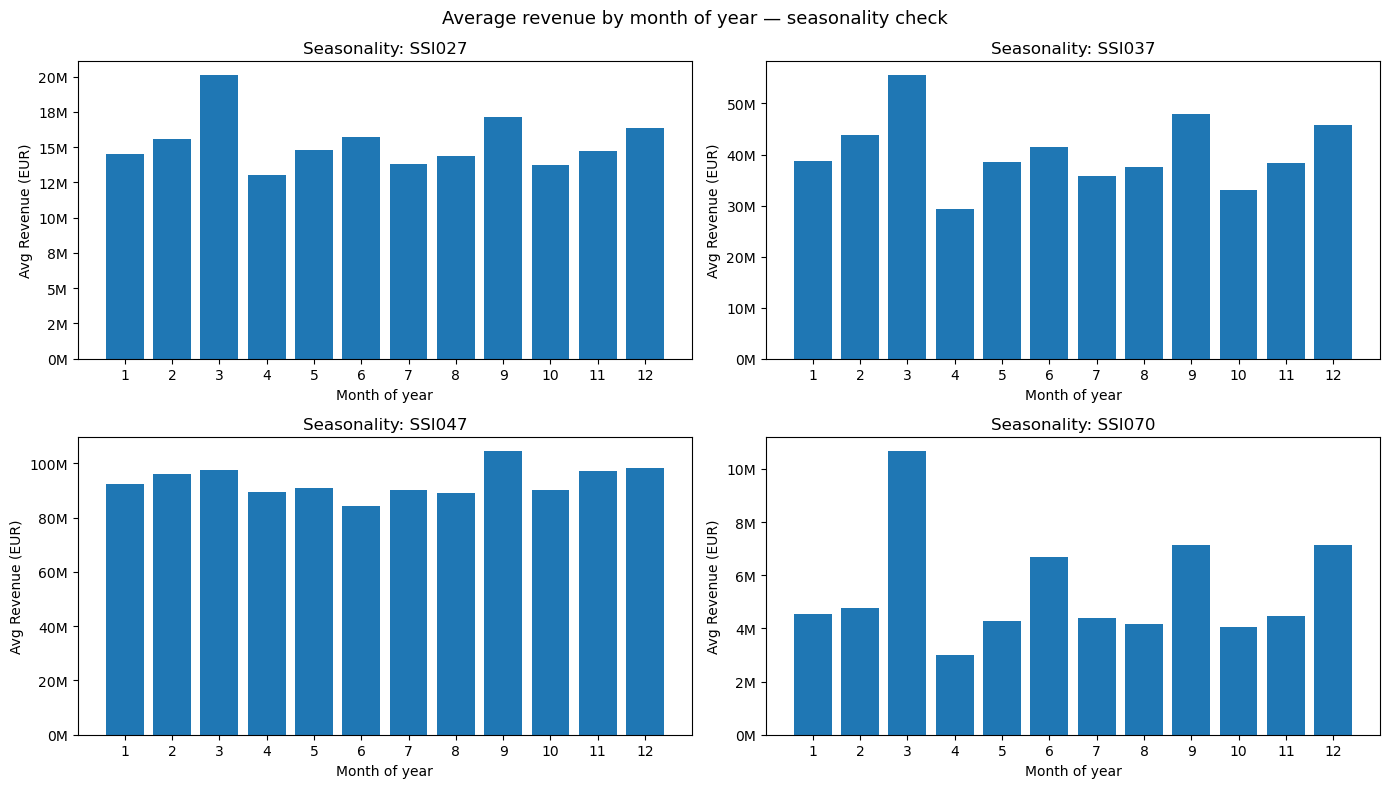

In [55]:
df_merged['Month'] = pd.to_datetime(df_merged['Date']).dt.month

seasonality = (
    df_merged.groupby(['Business_Unit', 'Month'])['Revenue']
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, bu in enumerate(sorted(df_merged['Business_Unit'].unique())):
    d = seasonality[seasonality['Business_Unit'] == bu]
    axes[i].bar(d['Month'], d['Revenue'])
    axes[i].set_title(f'Seasonality: {bu}')
    axes[i].set_xlabel('Month of year')
    axes[i].set_ylabel('Avg Revenue (EUR)')
    axes[i].set_xticks(range(1, 13))
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.suptitle('Average revenue by month of year — seasonality check', fontsize=13)
plt.tight_layout()
plt.savefig('seasonality.png', dpi=150)
plt.show()

#### 3.2.3. Hierarchy Proportions

In [56]:
seg_totals = (
    df_merged.groupby(['Period', 'Segment'])['Revenue']
    .sum()
    .reset_index()
    .rename(columns={'Revenue': 'Seg_Revenue'})
)

df_prop = df_merged.merge(seg_totals, on=['Period', 'Segment'], how='left')
df_prop['Proportion'] = df_prop['Revenue'] / df_prop['Seg_Revenue'].replace(0, np.nan)

avg_proportions = (
    df_prop.groupby(['Business_Unit', 'Segment', 'Subsegment'])['Proportion']
    .mean()
    .reset_index()
    .rename(columns={'Proportion': 'Avg_Proportion'})
    .sort_values(['Business_Unit', 'Segment', 'Avg_Proportion'], ascending=[True, True, False])
)

# display ALL proportions grouped by segment
pd.set_option('display.max_rows', None)
print("=== SUBSEGMENT PROPORTIONS WITHIN EACH SEGMENT ===")
print(avg_proportions.to_string(index=False))
pd.reset_option('display.max_rows')


=== SUBSEGMENT PROPORTIONS WITHIN EACH SEGMENT ===
Business_Unit  Segment Subsegment  Avg_Proportion
       SSI027 SSI02710   SSI02710    6.905476e-01
       SSI027 SSI02710 SSI0271002    2.884138e-01
       SSI027 SSI02710 SSI0271099    2.092467e-02
       SSI027 SSI02710 SSI0271006    1.139462e-04
       SSI027 SSI02710 SSI0271004    0.000000e+00
       SSI027 SSI02780 SSI0278002    6.748577e-01
       SSI027 SSI02780 SSI0278004    3.210052e-01
       SSI027 SSI02780 SSI0278006    2.193300e-03
       SSI027 SSI02780 SSI0278099    1.943820e-03
       SSI027 SSI02780   SSI02780   -1.504791e-08
       SSI027 SSI02782 SSI0278202    4.977674e-01
       SSI027 SSI02782 SSI0278204    2.966831e-01
       SSI027 SSI02782 SSI0278206    1.825339e-01
       SSI027 SSI02782 SSI0278208    1.999374e-02
       SSI027 SSI02782   SSI02782    1.418537e-03
       SSI027 SSI02782 SSI0278210    7.780190e-04
       SSI027 SSI02782 SSI0278212    4.922482e-04
       SSI027 SSI02782 SSI0278214    1.692429e-04

#### 3.2.4. Checking Sparsity — zero percentage per subsegment

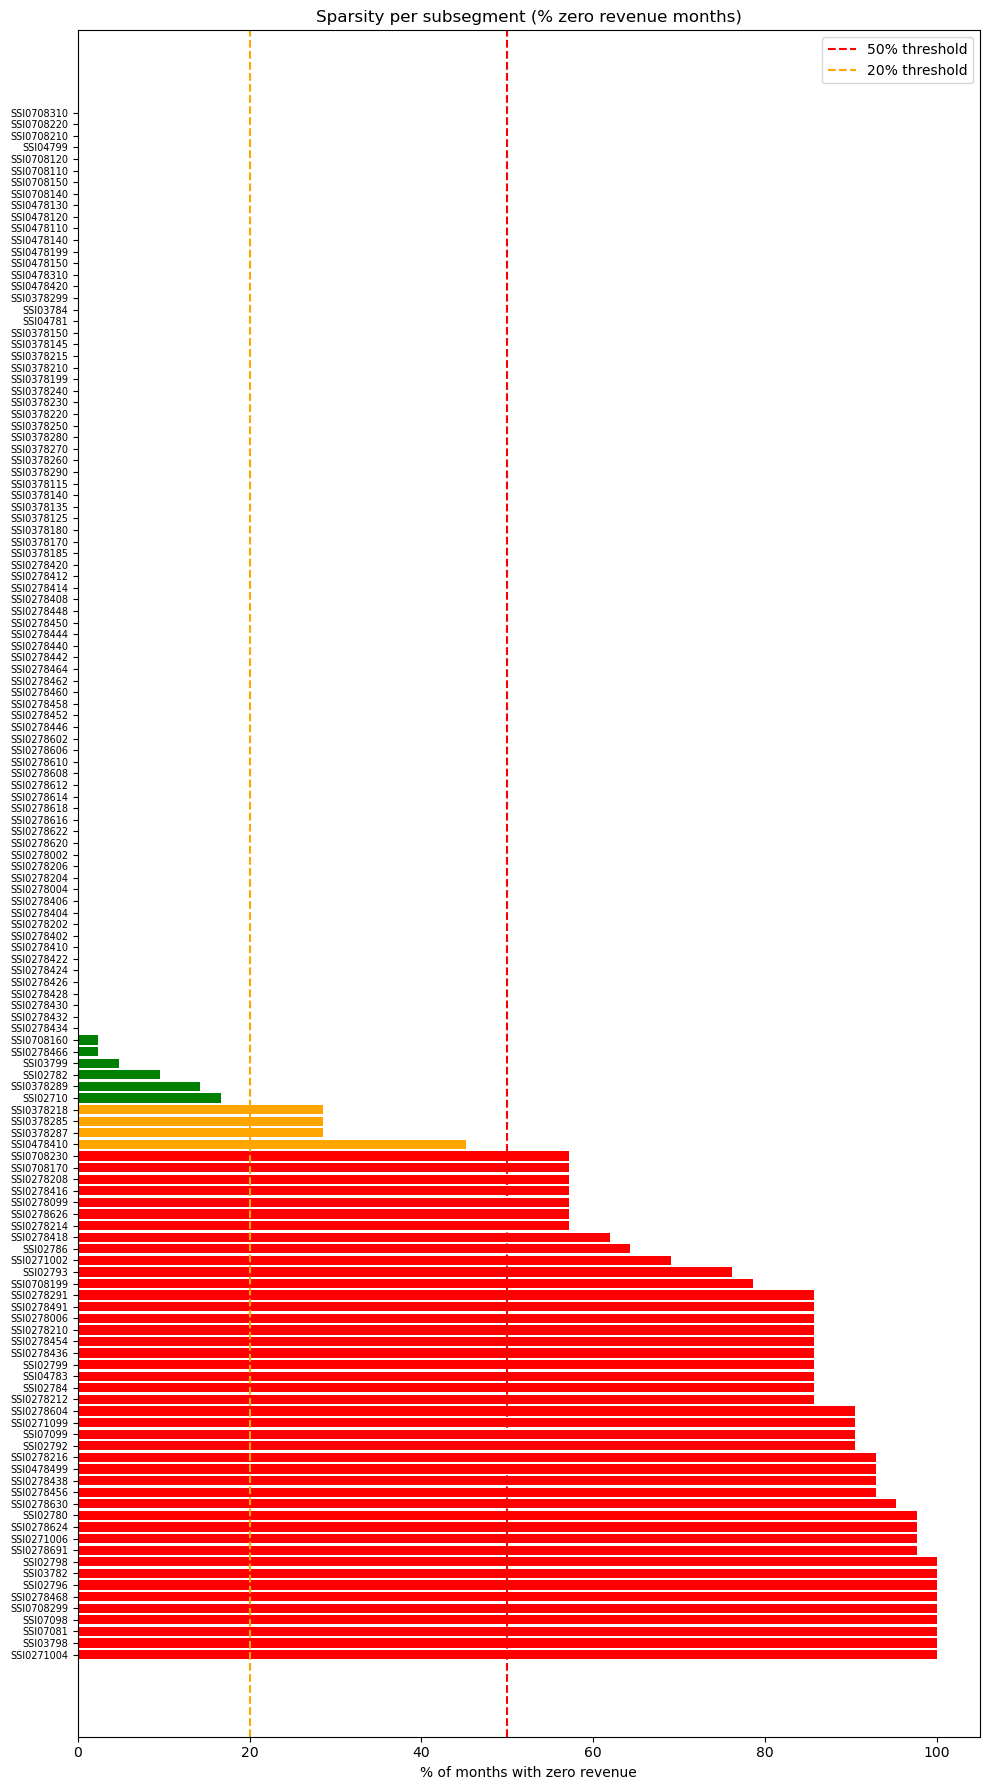

In [59]:
fig, ax = plt.subplots(figsize=(10, 18))
colors = ['red' if z > 50 else 'orange' if z > 20 else 'green' for z in zero_pct['Zero_Pct']]
ax.barh(zero_pct['Subsegment'], zero_pct['Zero_Pct'], color=colors)
ax.axvline(50, color='red', linestyle='--', label='50% threshold')
ax.axvline(20, color='orange', linestyle='--', label='20% threshold')
ax.set_xlabel('% of months with zero revenue')
ax.set_title('Sparsity per subsegment (% zero revenue months)')
ax.tick_params(axis='y', labelsize=7)
ax.legend()
plt.tight_layout()
plt.savefig('sparsity.png', dpi=150)
plt.show()

In [60]:
print("\nSubsegments with >50% zero months (consider excluding from model):")
print(zero_pct[zero_pct['Zero_Pct'] > 50][['Segment', 'Subsegment', 'Zero_Pct']].to_string(index=False))


Subsegments with >50% zero months (consider excluding from model):
 Segment Subsegment   Zero_Pct
SSI02710 SSI0271004 100.000000
SSI03798   SSI03798 100.000000
SSI07081   SSI07081 100.000000
SSI07098   SSI07098 100.000000
SSI07082 SSI0708299 100.000000
SSI02784 SSI0278468 100.000000
SSI02796   SSI02796 100.000000
SSI03782   SSI03782 100.000000
SSI02798   SSI02798 100.000000
SSI02786 SSI0278691  97.619048
SSI02710 SSI0271006  97.619048
SSI02786 SSI0278624  97.619048
SSI02780   SSI02780  97.619048
SSI02786 SSI0278630  95.238095
SSI02784 SSI0278456  92.857143
SSI02784 SSI0278438  92.857143
SSI04784 SSI0478499  92.857143
SSI02782 SSI0278216  92.857143
SSI02792   SSI02792  90.476190
SSI07099   SSI07099  90.476190
SSI02710 SSI0271099  90.476190
SSI02786 SSI0278604  90.476190
SSI02782 SSI0278212  85.714286
SSI02784   SSI02784  85.714286
SSI04783   SSI04783  85.714286
SSI02799   SSI02799  85.714286
SSI02784 SSI0278436  85.714286
SSI02784 SSI0278454  85.714286
SSI02782 SSI0278210  85.714286
SS

#### 3.2.5. Correlation between Market Variables and Total Revenue


=== TOP 20 MARKET VARIABLES CORRELATED WITH TOTAL REVENUE ===
                     Market_Variable  Abs_Correlation
                     Switzerland_GDP         0.738449
                   United_States_GDP         0.730418
         Italy_GDP_from_Construction         0.719797
                  United_Kingdom_GDP         0.718634
                 China_Interest_Rate         0.706348
       Germany_GDP_from_Construction         0.680555
                           Italy_GDP         0.680211
               United_States_Exports         0.673707
        United_Kingdom_Interest_Rate         0.662412
United_Kingdom_GDP_from_Construction         0.653288
                       Japan_Exports         0.643316
         United_States_Interest_Rate         0.635619
                         Germany_GDP         0.631302
                           China_GDP         0.628168
                France_Interest_Rate         0.621659
               Germany_Interest_Rate         0.621659
                 It

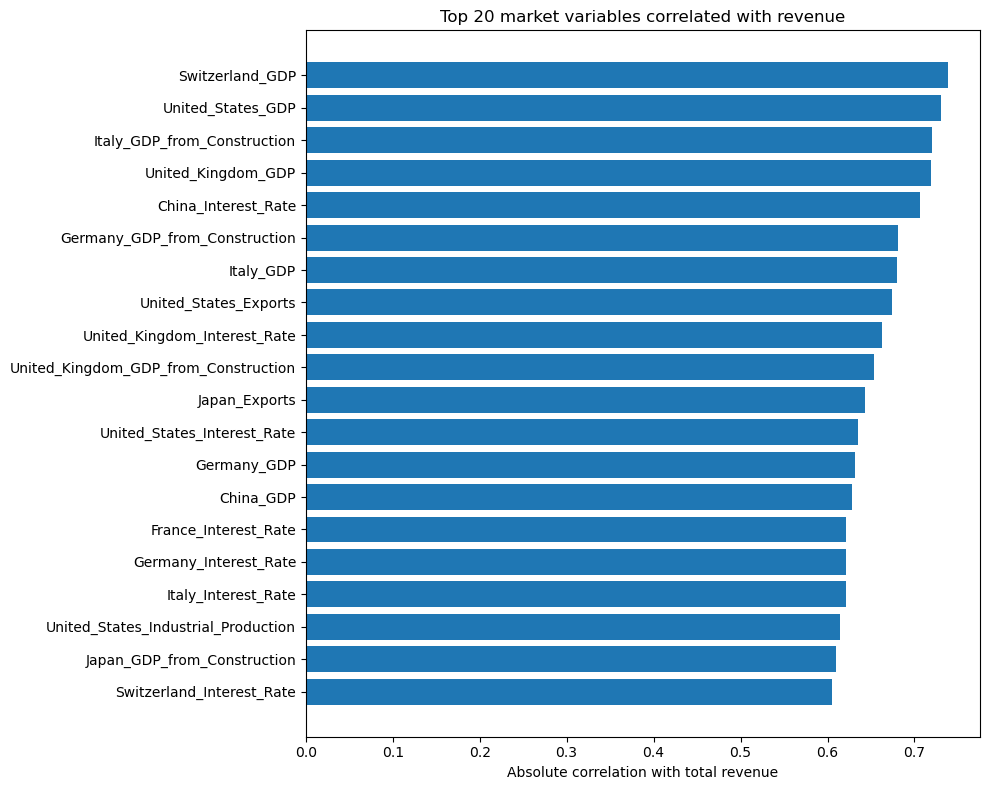

In [ ]:
market_cols = [c for c in df_merged.columns if any(
    c.startswith(country) for country in
    ['Germany', 'France', 'China', 'Italy', 'Japan',
     'Switzerland', 'United_Kingdom', 'United_States']
)]

total_rev_period = df_merged.groupby('Period')['Revenue'].sum().reset_index()
market_period    = df_merged.groupby('Period')[market_cols].mean().reset_index()
corr_df          = total_rev_period.merge(market_period, on='Period')

correlations = (
    corr_df[market_cols]
    .corrwith(corr_df['Revenue'])
    .abs()
    .sort_values(ascending=False)
    .reset_index()
)
correlations.columns = ['Market_Variable', 'Abs_Correlation']

print("\n=== TOP 20 MARKET VARIABLES CORRELATED WITH TOTAL REVENUE ===")
print(correlations.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
top20 = correlations.head(20)
ax.barh(top20['Market_Variable'], top20['Abs_Correlation'])
ax.set_xlabel('Absolute correlation with total revenue')
ax.set_title('Top 20 market variables correlated with revenue')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 3.3. Checking Duplicates

In [92]:
#checking number of duplicates
train_data.duplicated().sum()

np.int64(0)

In [93]:
#checking number of duplicates
df_market.duplicated().sum()

np.int64(0)

- None of the datasets present duplicates.

### 3.4. Checking Missing Values

In [94]:
#checking number of missing values
train_data.isna().sum()

Period           0
Biz_Desc         0
Business_Unit    0
Segment          0
Subsegment       0
Orders           0
Revenue          0
dtype: int64

- The train dataset does not present any missing values which is a good sign.

In [95]:
#checking number of missing values
df_market.isna().sum()

Period                                        0
China_Core_Inflation_Rate                     2
China_Exports                                 2
China_GDP                                   165
China_GDP_from_Construction                 120
China_GDP_from_Manufacturing                120
China_Industrial_Production                   4
China_Industrial_Production_Mom              10
China_Inflation_Rate                          2
China_Interest_Rate                          43
China_Steel_Production                        0
France_Core_Inflation_Rate                    2
France_Exports                                2
France_GDP                                  165
France_GDP_from_Construction                120
France_GDP_from_Manufacturing               120
France_Industrial_Production                  2
France_Industrial_Production_Mom              2
France_Inflation_Rate                         2
France_Interest_Rate                          4
France_Steel_Production                 

In [96]:
pd.set_option('display.max_rows', None)
df_market.isna().sum()/len(df_market) * 100

Period                                       0.000000
China_Core_Inflation_Rate                    1.111111
China_Exports                                1.111111
China_GDP                                   91.666667
China_GDP_from_Construction                 66.666667
China_GDP_from_Manufacturing                66.666667
China_Industrial_Production                  2.222222
China_Industrial_Production_Mom              5.555556
China_Inflation_Rate                         1.111111
China_Interest_Rate                         23.888889
China_Steel_Production                       0.000000
France_Core_Inflation_Rate                   1.111111
France_Exports                               1.111111
France_GDP                                  91.666667
France_GDP_from_Construction                66.666667
France_GDP_from_Manufacturing               66.666667
France_Industrial_Production                 1.111111
France_Industrial_Production_Mom             1.111111
France_Inflation_Rate       

- The variables whose missing values represent more than 50% of the data correspond to columns that have informatio about the GDP
Some columns present a high amount of missing values- almost 92% of the total data. In those cases, the information given is not sufficiently significant to consider these variables.
- 

- Data that have more than 50% of missing observations correspond to the GDP columns of each country (for example, China_GDP, China_GDP_from_Construction, China_GDP_from_Manufacturing, etc). In these cases, it is normal for the GDP to have a high quantity of missing values considering that the GDP of each country can only be calculated at the end of each year and since we have our data per month, this is the usual behavior. 
- The rest of the columns have less than 50% of missing values (usually the values do not exceed 5%, except for steel production).For the columns corresponding to steel production, there are some countries that for the possitive months (the ones we are going to consider later on merge) have 100% of missing values. 

In [97]:
#creating a variable that has df_market data from the 1 to 42 months 
df_market_months = df_market[df_market['Period'].between(1, 42)]

In [98]:
pd.set_option('display.max_rows', None)
df_market_months.isna().sum()/len(df_market_months) * 100

Period                                        0.000000
China_Core_Inflation_Rate                     0.000000
China_Exports                                 0.000000
China_GDP                                    92.857143
China_GDP_from_Construction                  66.666667
China_GDP_from_Manufacturing                 66.666667
China_Industrial_Production                   2.380952
China_Industrial_Production_Mom               0.000000
China_Inflation_Rate                          0.000000
China_Interest_Rate                           0.000000
China_Steel_Production                        0.000000
France_Core_Inflation_Rate                    0.000000
France_Exports                                0.000000
France_GDP                                   92.857143
France_GDP_from_Construction                 66.666667
France_GDP_from_Manufacturing                66.666667
France_Industrial_Production                  0.000000
France_Industrial_Production_Mom              0.000000
France_Inf

- If we consider only the observations whose period we are going to consider when merging with *train_data*, some of these observations have 100% missing values. In those cases, it is useless to consider them. 
- All variables that have missing values, also have a high percentage (>60%), except for *United_States_Interest_Rate* that has only 2.3% and *China_Industrial_Production* that has 2.3%. Therefore, these are the only variables worth of handling missing values.

### 3.5. Checking Outliers

In [99]:
#setting metric fearures for train_data
metric_features_train= ['Revenue', 'Orders']

In [100]:
#setting metric fearures for df_market
metric_features_market= ['China_Core_Inflation_Rate', 'China_Exports', 'China_GDP', 
                         'China_Industrial_Production', 'China_Industrial_Production_Mom', 
                         'China_Inflation_Rate', 'China_Interest_Rate', 'China_Steel_Production', 
                         'France_Core_Inflation_Rate', 'France_Exports', 'France_Industrial_Production',
                         'France_Industrial_Production_Mom', 'France_Inflation_Rate', 'France_Interest_Rate', 
                         'Germany_Core_Inflation_Rate', 'Germany_Exports', 'Germany_Industrial_Production', 
                         'Germany_Industrial_Production_Mom', 'Germany_Inflation_Rate', 'Germany_Interest_Rate', 
                         'Germany_Steel_Production', 'Italy_Core_Inflation_Rate', 'Italy_Exports', 'Italy_Industrial_Production',
                         'Italy_Industrial_Production_Mom', 'Italy_Inflation_Rate', 'Italy_Interest_Rate', 'Japan_Core_Inflation_Rate',
                         'Japan_Exports', 'Japan_Industrial_Production', 'Japan_Industrial_Production_Mom', 'Japan_Inflation_Rate', 
                         'Japan_Interest_Rate', 'Japan_Steel_Production', 'Switzerland_Core_Inflation_Rate', 'Switzerland_Exports', 
                         'Switzerland_Inflation_Rate', 'Switzerland_Interest_Rate', 'United_Kingdom_Core_Inflation_Rate', 'United_Kingdom_Exports', 
                         'United_Kingdom_Industrial_Production', 'United_Kingdom_Industrial_Production_Mom', 'United_Kingdom_Inflation_Rate', 
                         'United_Kingdom_Interest_Rate', 'United_States_Core_Inflation_Rate', 'United_States_Exports', 
                         'United_States_Industrial_Production', 'United_States_Industrial_Production_Mom', 'United_States_Inflation_Rate', 
                         'United_States_Steel_Production'
]

In [101]:
def plot_multiple_boxplots(data, feats, n_cols=2, title="Numeric Variables - Box Plots"):

    #defining grid size
    n_rows = ceil(len(feats) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows)
    )

    axes = axes.flatten()
    #looping through features
    for i, feat in enumerate(feats):

        #keeping ALL values except missing ones
        values = data[feat].dropna()

        #plotting only if there is data
        if len(values) > 0:
            sns.boxplot(x=values, ax=axes[i], color="#798a40")
            axes[i].set_title(feat, fontsize=10)
        else:
            axes[i].set_title(f"{feat} (no data)", fontsize=10)

    # removing empty subplots
    for j in range(len(feats), len(axes)):
        fig.delaxes(axes[j])

    # final layout adjustments
    plt.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

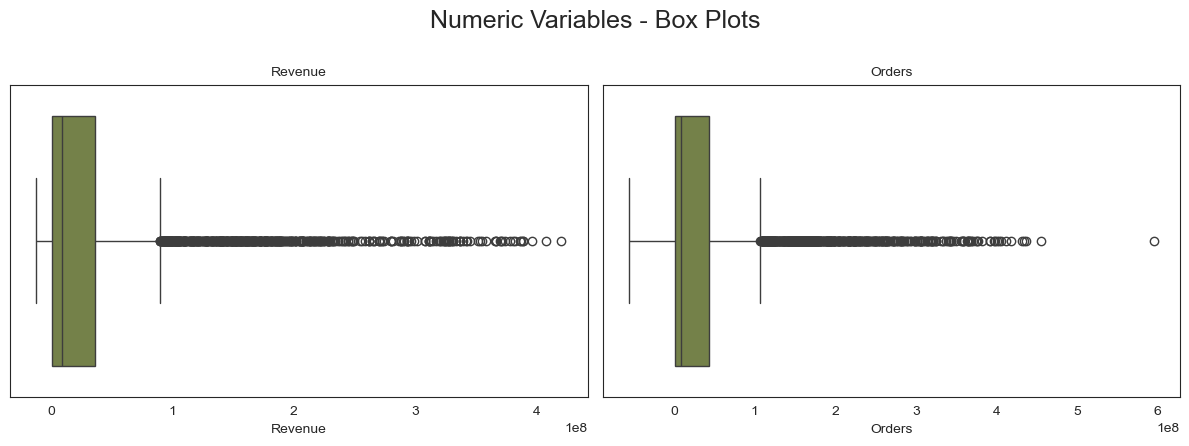

In [102]:
#applying the function to our numerical features
plot_multiple_boxplots(train_data, metric_features_train)

In [103]:
def plot_multiple_boxplots(data, feats, n_cols=3, title="Numeric Variables - Box Plots"):

    #defining grid size
    n_rows = ceil(len(feats) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows)
    )

    axes = axes.flatten()
    #looping through features
    for i, feat in enumerate(feats):

        #keeping ALL values except missing ones
        values = data[feat].dropna()

        #plotting only if there is data
        if len(values) > 0:
            sns.boxplot(x=values, ax=axes[i], color="#798a40")
            axes[i].set_title(feat, fontsize=10)
        else:
            axes[i].set_title(f"{feat} (no data)", fontsize=10)

    # removing empty subplots
    for j in range(len(feats), len(axes)):
        fig.delaxes(axes[j])

    # final layout adjustments
    plt.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

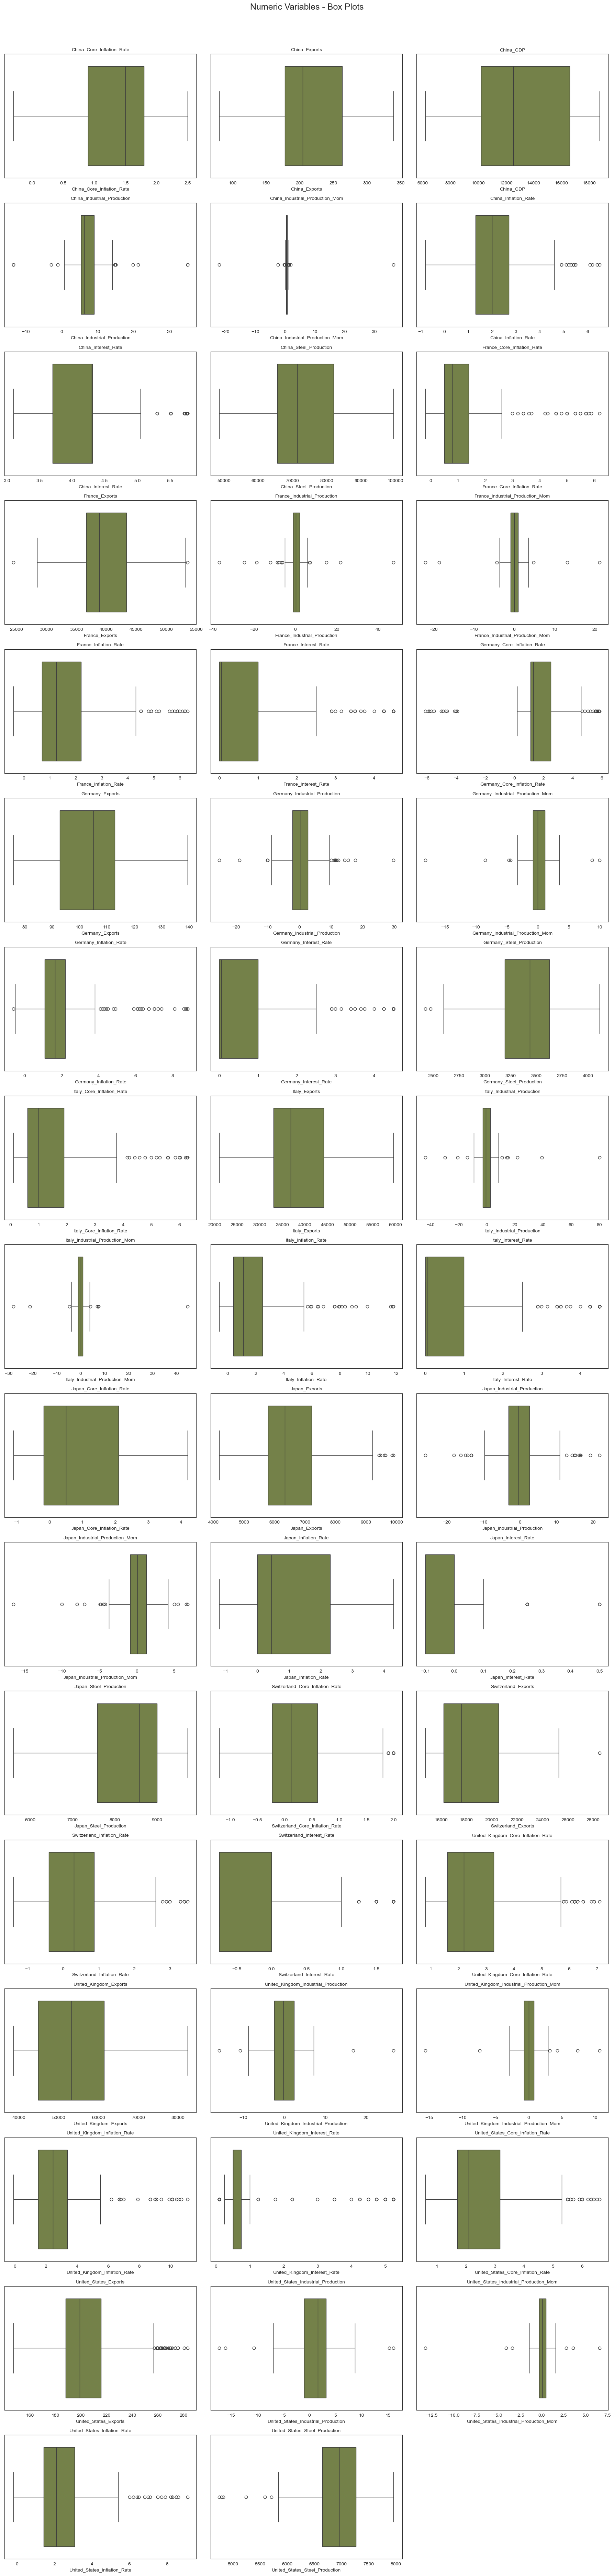

In [104]:
#applying the function to our numerical features
plot_multiple_boxplots(df_market, metric_features_market)

- Even tough there are some outliers, these values correspond to real macroeconomic indicators (like inflation, post-COVID period, etc.). If we applied some capping or transformation to try handle them, we would be distorting the actual economic reality that your model needs to learn from. Therefore, we have decided to keep the data as it is for now. 

### 3.6. Checking Distribution

In [105]:
df= pd.DataFrame(train_data[metric_features_train])

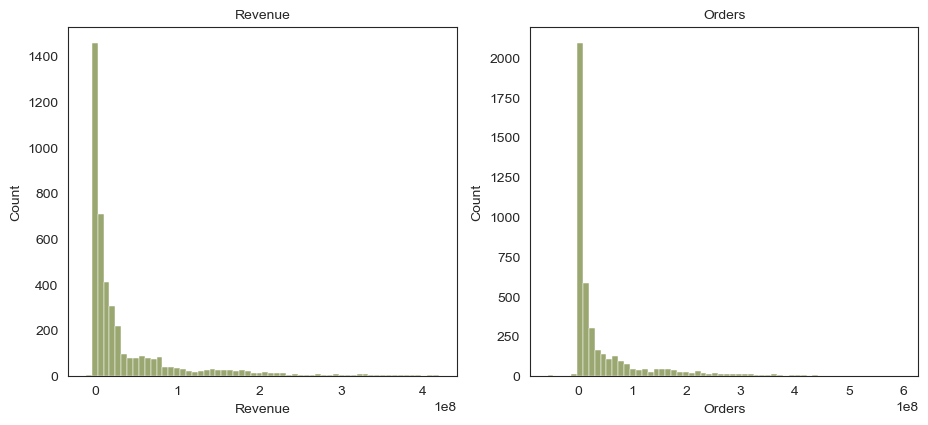

In [106]:
#setting visual style
sns.set_style("white")  # clean background for reports
#sampling the dataset
N = 200_000
sample = train_data.sample(n=min(N, len(train_data)), random_state=42)

#selecting numeric variables
cols = metric_features_train

#defining plotting structure
plots_per_fig = 6   
n_figs = ceil(len(cols) / plots_per_fig)

#looping through figures
for f in range(n_figs):
    
    #selecting subset of columns for current figure
    start = f * plots_per_fig
    end = start + plots_per_fig
    subset_cols = cols[start:end]
    
    #creating subplot grid
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    
    #ploting histograms
    for ax, col in zip(axes, subset_cols):
        
        #removing missing values only 
        data = sample[col].dropna()
        
        sns.histplot(
            data,
            bins=60,
            kde=False,
            ax=ax,
            color="#798a40"   
        )
        
        ax.set_title(col, fontsize=10)

    #removing empty subplots
    for j in range(len(subset_cols), len(axes)):
        fig.delaxes(axes[j])
    
        #adjusting layout and display
    plt.tight_layout()
    plt.show()

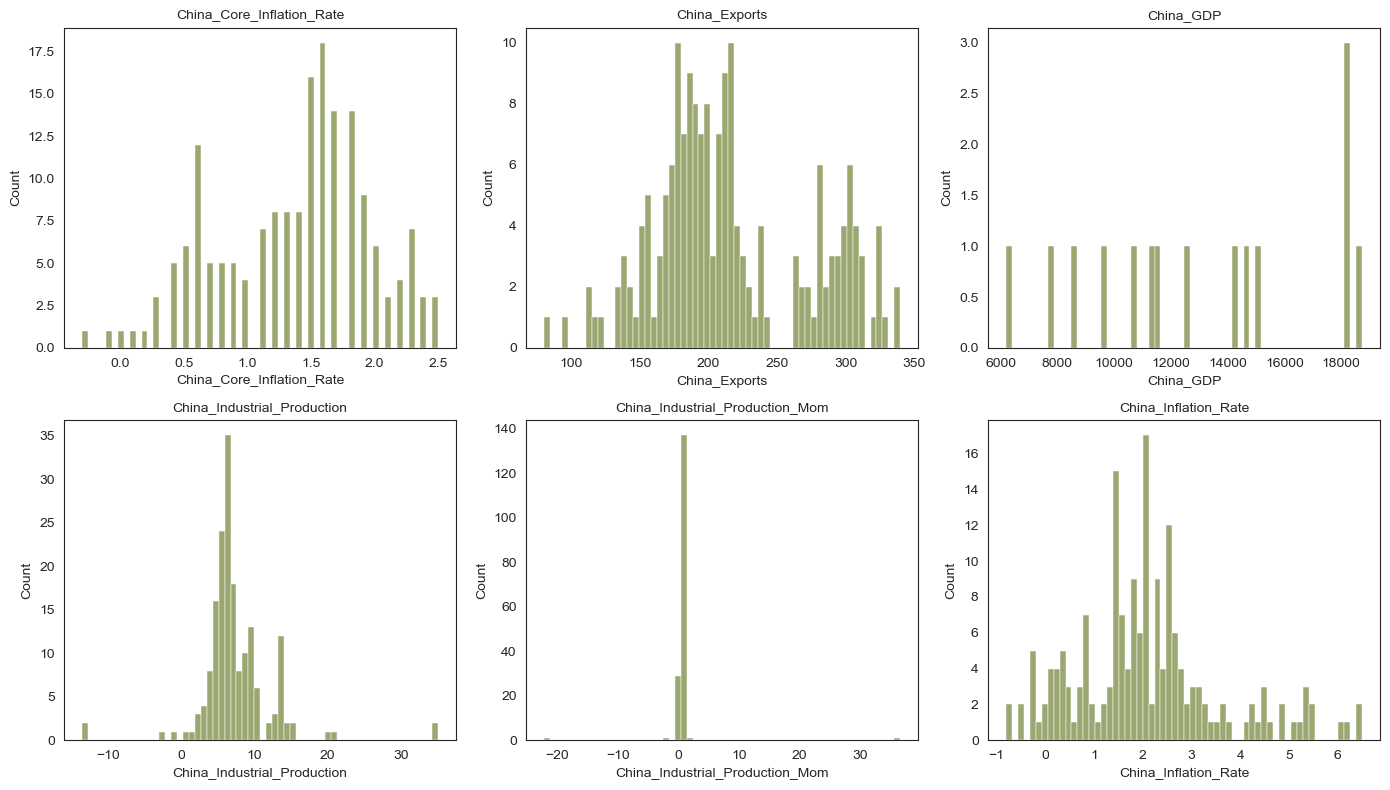

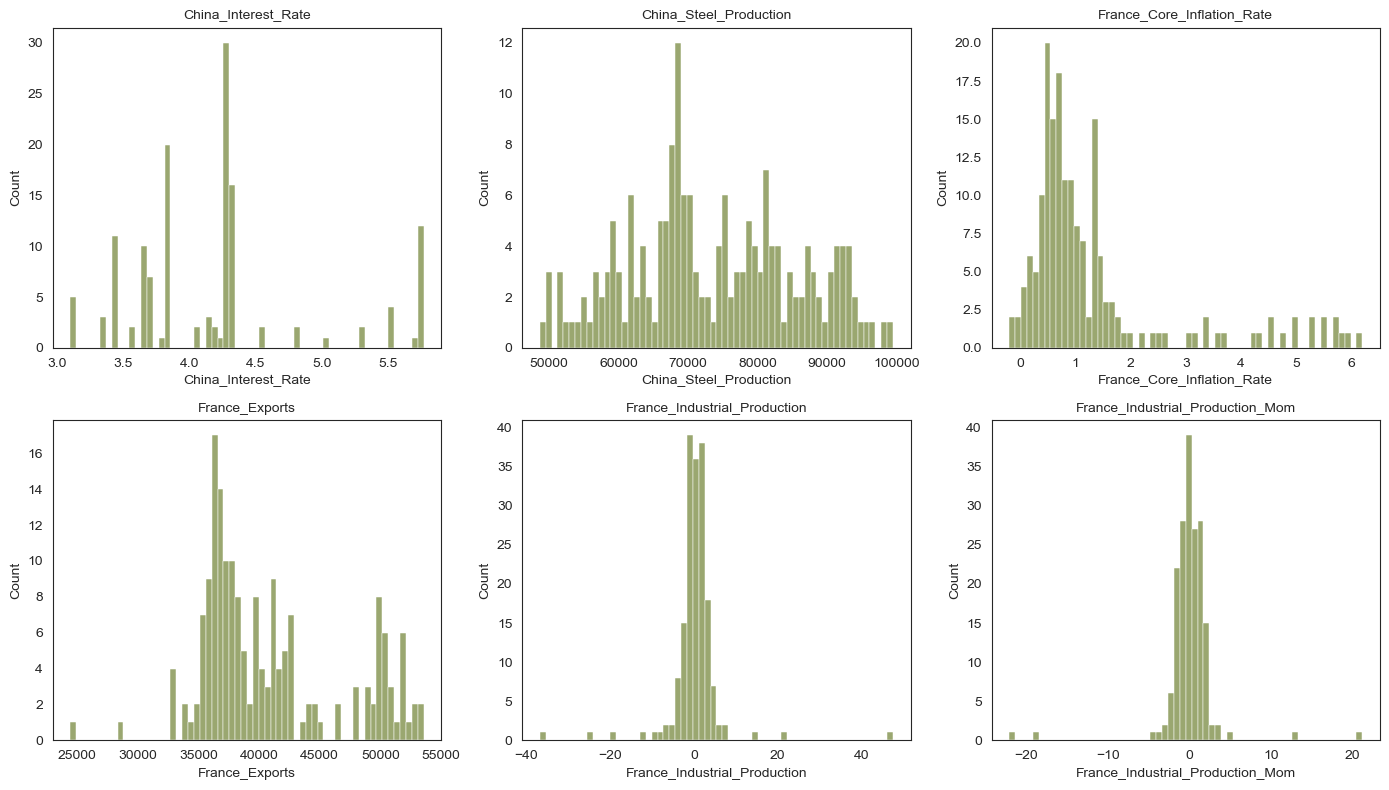

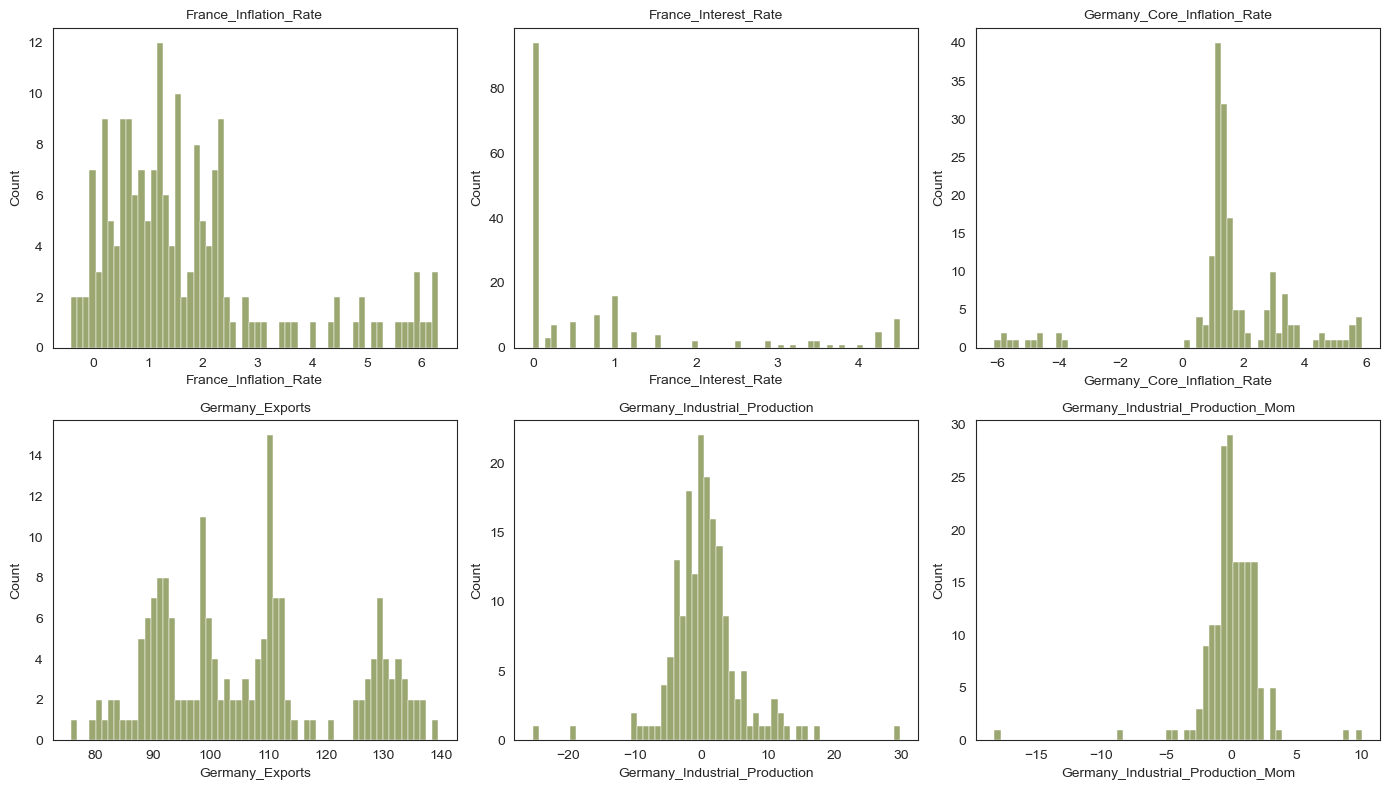

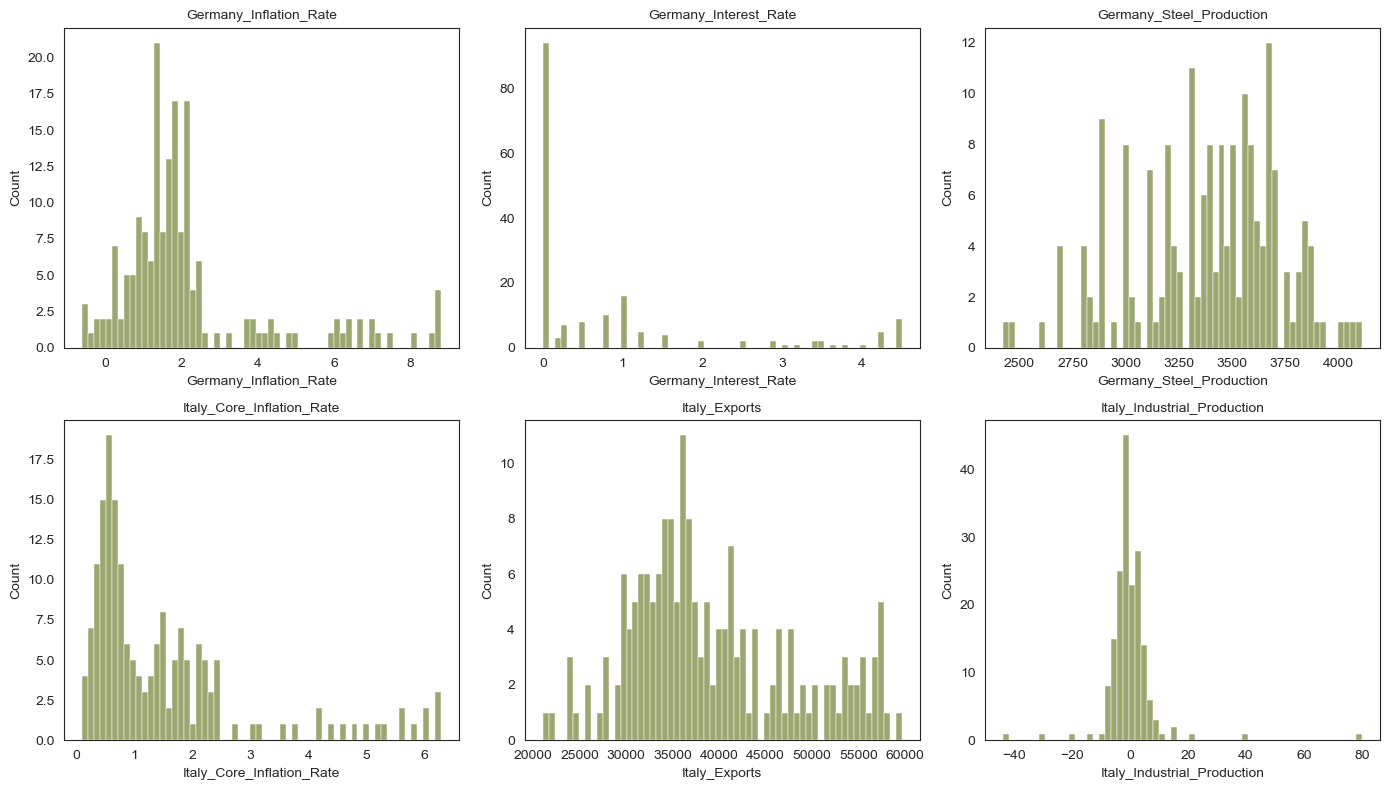

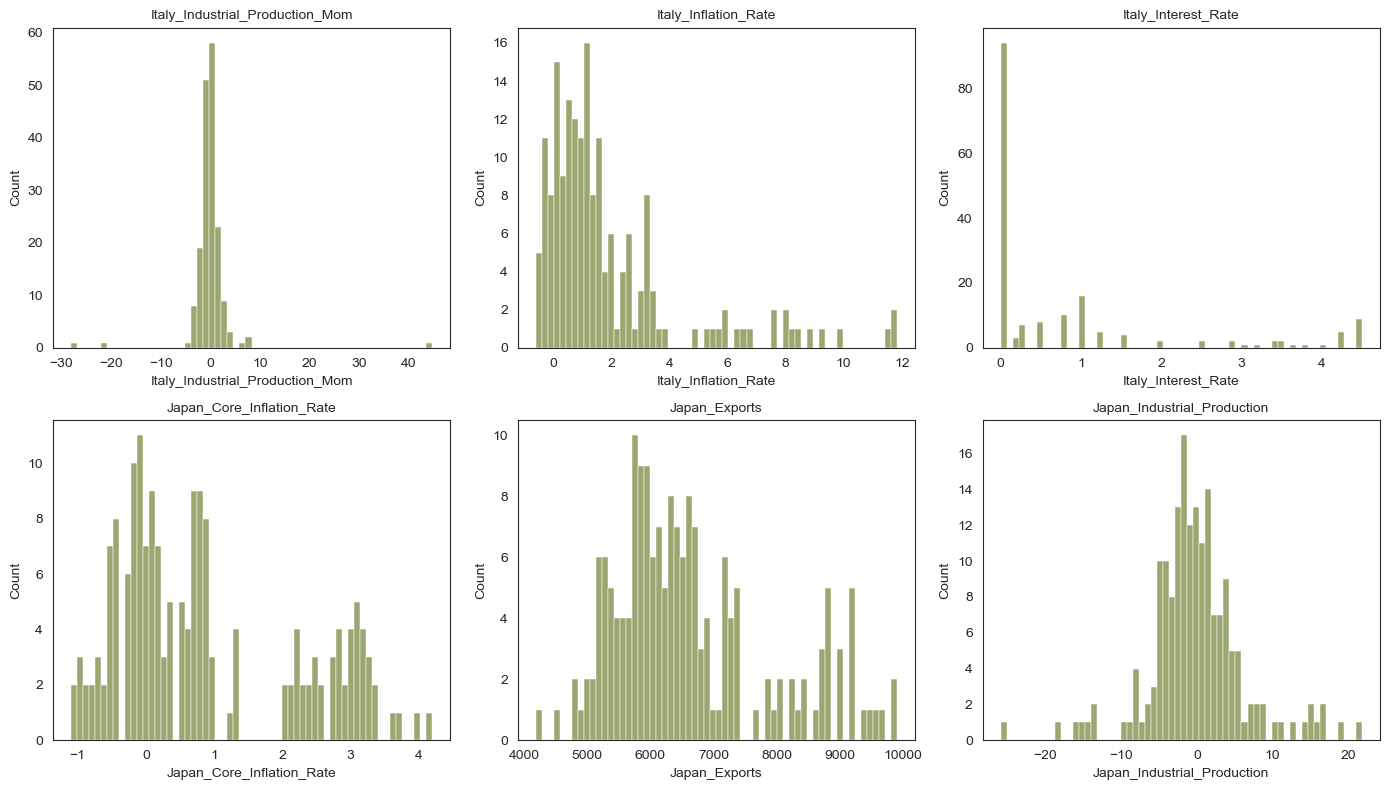

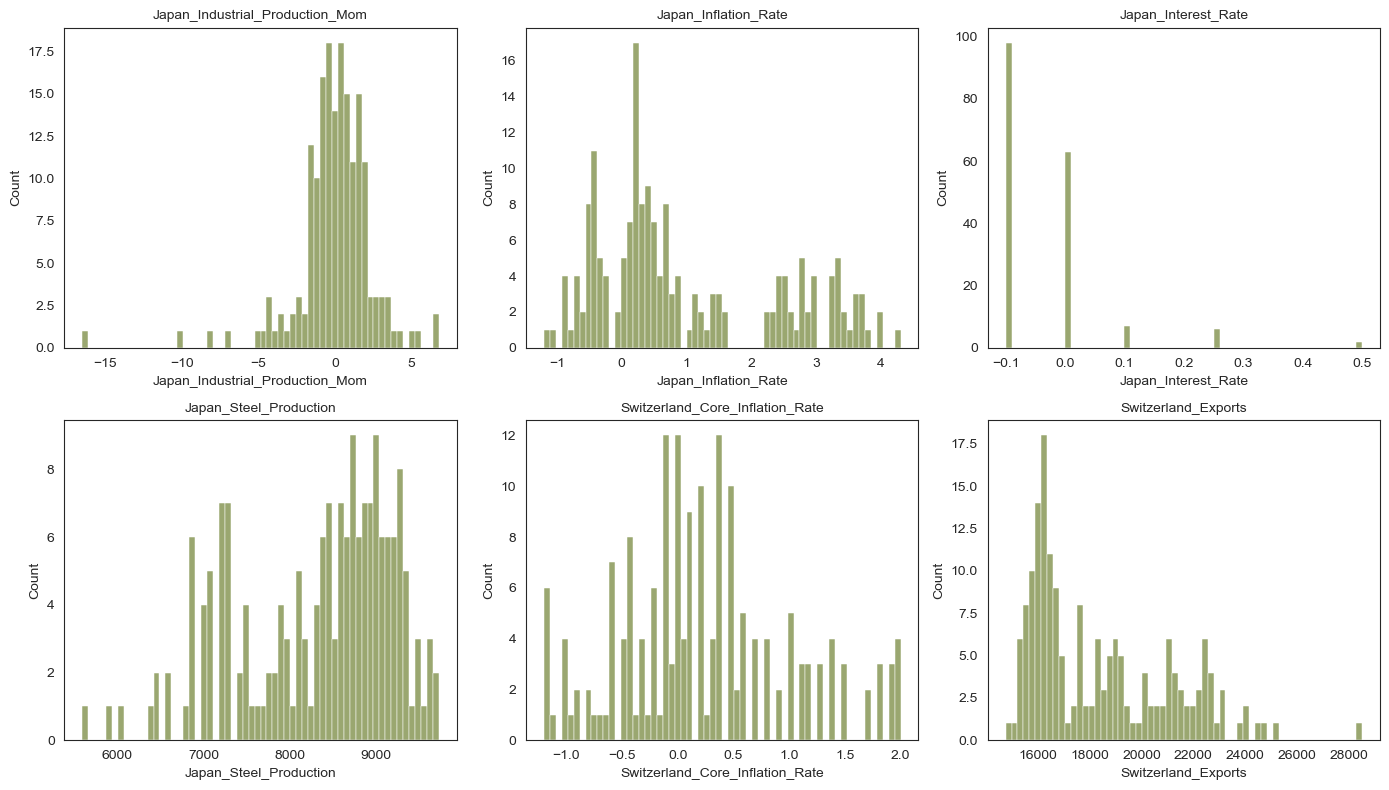

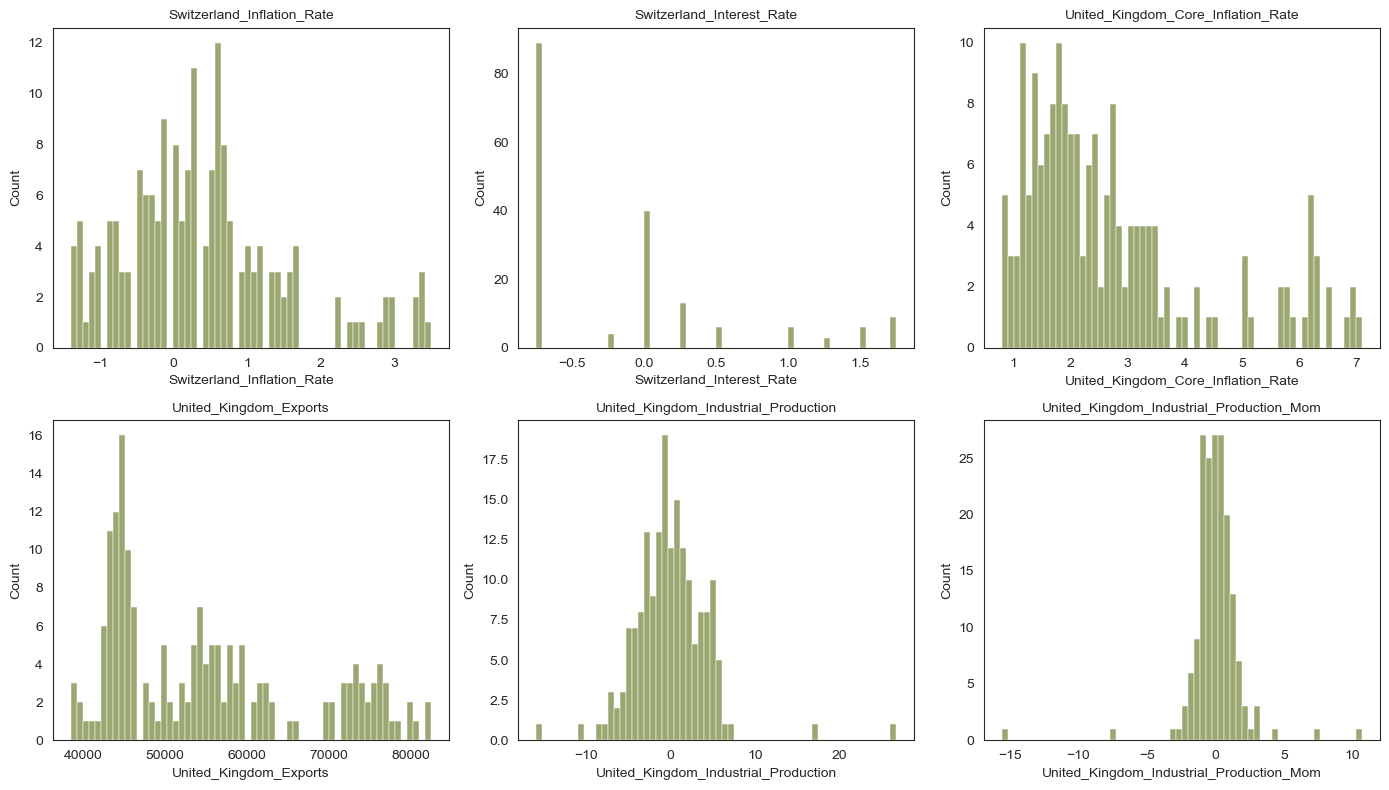

KeyboardInterrupt: 

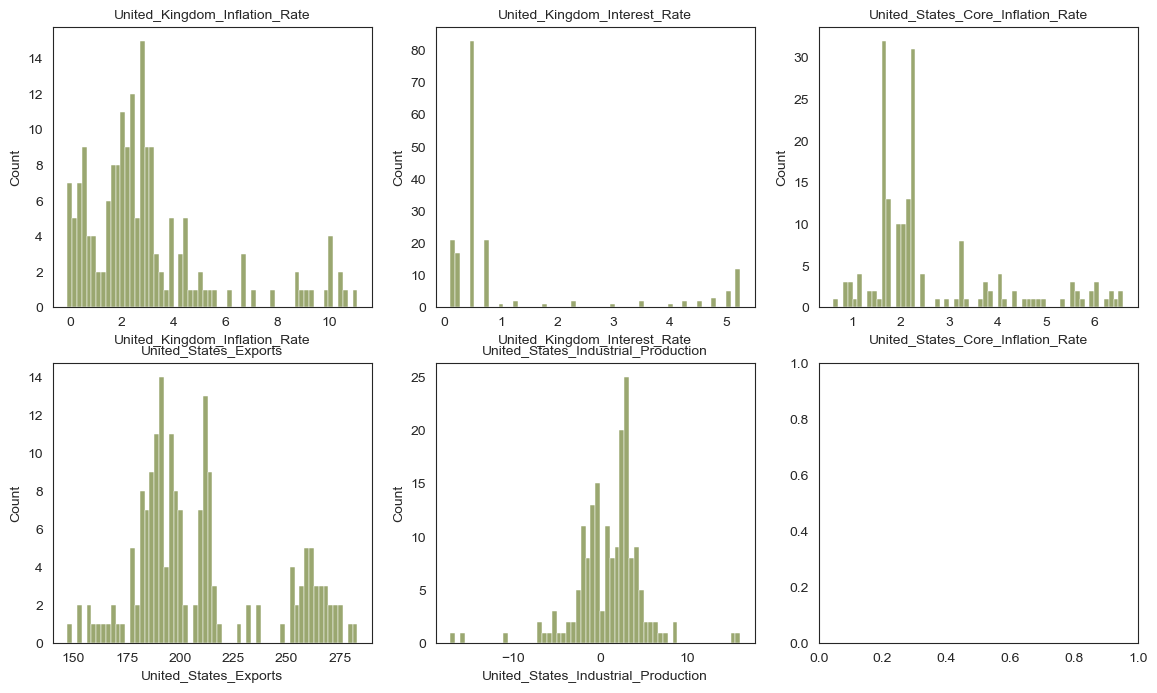

In [107]:
#setting visual style
sns.set_style("white")  # clean background for reports
#sampling the dataset
N = 200_000
sample = df_market.sample(n=min(N, len(df_market)), random_state=42)

#selecting numeric variables
cols = metric_features_market

#defining plotting structure
plots_per_fig = 6   
n_figs = ceil(len(cols) / plots_per_fig)

#looping through figures
for f in range(n_figs):
    
    #selecting subset of columns for current figure
    start = f * plots_per_fig
    end = start + plots_per_fig
    subset_cols = cols[start:end]
    
    #creating subplot grid
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    
    #ploting histograms
    for ax, col in zip(axes, subset_cols):
        
        #removing missing values only 
        data = sample[col].dropna()
        
        sns.histplot(
            data,
            bins=60,
            kde=False,
            ax=ax,
            color="#798a40"   
        )
        
        ax.set_title(col, fontsize=10)

    #removing empty subplots
    for j in range(len(subset_cols), len(axes)):
        fig.delaxes(axes[j])
    
        #adjusting layout and display
    plt.tight_layout()
    plt.show()

### 3.7. Checking Correlation between variables

In [ ]:
#checking correlation between variables 
#we are going to use spearman correlation since our variables do not follow a normal distribution
cor_spearman = df_market[metric_features_market].corr(method ='spearman')
cor_spearman

,China_Core_Inflation_Rate,China_Exports,China_GDP,China_Industrial_Production,China_Industrial_Production_Mom,China_Inflation_Rate,China_Interest_Rate,China_Steel_Production,France_Core_Inflation_Rate,France_Exports,...,United_Kingdom_Industrial_Production,United_Kingdom_Industrial_Production_Mom,United_Kingdom_Inflation_Rate,United_Kingdom_Interest_Rate,United_States_Core_Inflation_Rate,United_States_Exports,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Steel_Production
China_Core_Inflation_Rate,1.000000,-0.601535,-0.641005,0.350778,0.110067,0.489509,0.763456,-0.519185,-0.470539,-0.445736,...,0.129136,0.063294,-0.045124,-0.278393,-0.419716,-0.410172,0.244042,0.004236,-0.203296,0.346979
China_Exports,-0.601535,1.000000,0.932143,-0.534005,-0.253287,-0.556201,-0.716840,0.765034,0.413557,0.755412,...,-0.067462,-0.037299,0.165909,0.332794,0.594231,0.779905,-0.144228,-0.012998,0.491679,-0.088536
China_GDP,-0.641005,0.932143,1.000000,-0.705988,-0.536429,-0.694721,-0.943685,0.807143,0.481217,0.942857,...,-0.058981,-0.201966,0.175000,0.403616,0.703146,0.910714,-0.480787,-0.304388,0.550985,-0.175000
China_Industrial_Production,0.350778,-0.534005,-0.705988,1.000000,0.483968,0.298135,0.475174,-0.574685,-0.303811,-0.630758,...,0.088079,-0.068754,0.003491,-0.349172,-0.597015,-0.527057,0.388441,0.171938,-0.232295,0.212601
China_Industrial_Production_Mom,0.110067,-0.253287,-0.536429,0.483968,1.000000,0.304943,0.031023,-0.199254,-0.143508,-0.453833,...,-0.057605,-0.015859,-0.015704,-0.163640,-0.408471,-0.410135,-0.062856,0.074491,-0.183883,-0.031805
China_Inflation_Rate,0.489509,-0.556201,-0.694721,0.298135,0.304943,1.000000,0.473119,-0.457820,-0.131786,-0.592795,...,-0.106269,0.034190,0.105715,-0.117586,-0.334955,-0.541774,0.289531,0.082164,-0.142046,0.358545
China_Interest_Rate,0.763456,-0.716840,-0.943685,0.475174,0.031023,0.473119,1.000000,-0.594454,-0.732886,-0.712972,...,0.504204,0.089586,-0.518614,-0.386924,-0.649751,-0.619018,0.170641,-0.071090,-0.632366,0.397936
China_Steel_Production,-0.519185,0.765034,0.807143,-0.574685,-0.199254,-0.457820,-0.594454,1.000000,0.242274,0.664963,...,0.081263,0.012418,-0.018187,0.186418,0.454955,0.655751,-0.306479,0.051236,0.344398,-0.123561
France_Core_Inflation_Rate,-0.470539,0.413557,0.481217,-0.303811,-0.143508,-0.131786,-0.732886,0.242274,1.000000,0.558090,...,-0.434278,-0.130584,0.638881,0.565150,0.710207,0.464588,0.095544,-0.001930,0.687309,-0.015814
France_Exports,-0.445736,0.755412,0.942857,-0.630758,-0.453833,-0.592795,-0.712972,0.664963,0.558090,1.000000,...,-0.053031,-0.020413,0.274422,0.566934,0.774614,0.892917,-0.164116,-0.113626,0.580744,-0.117215


In [ ]:
#creating correlation matrix to facilitate interpretation
def cor_heatmap(cor):
    
    #setting the figure size
    plt.figure(figsize=(12, 10))

    #creating a mask for the upper triangle of the matrix (to avoid plotting duplicate correlation values)
    mask = np.triu(np.ones_like(cor, dtype=bool))

    #plotting the correlation heatmap
    sns.heatmap(
        data=cor,                 #correlation matrix input
        mask=mask,                #applying upper-triangle mask
        annot=True,               #displaying correlation coefficients
        cmap=sns.light_palette("#798a40", as_cmap=True), #color map for visual contrast
        fmt='.2f',                #formatting values to two decimals
        square=True,              #ensuring square-shaped cells
        linewidths=0.5,           #adding grid lines between cells
        cbar_kws={"shrink": 0.8}  #adjusting color bar size
    )

    #adding a title and display the plot
    plt.title("Spearman Correlation Matrix", fontsize=14)
    plt.show()

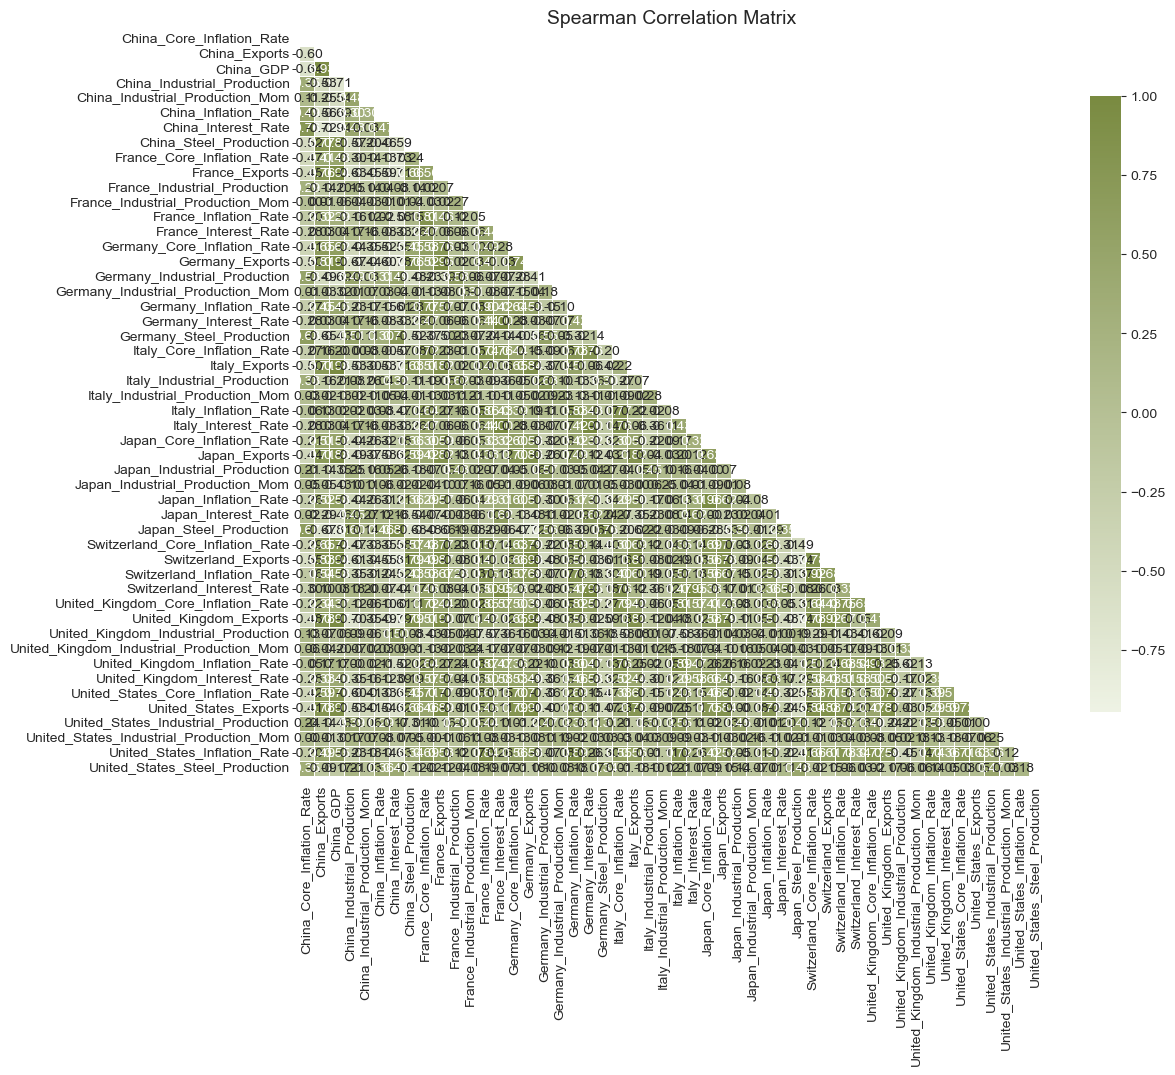

In [ ]:
#applying the function to our numerical features
cor_heatmap(cor_spearman)

## 4. Data Preparation

### 4.1. Handling Missing Values

- For columns with >50% missing values (corresponding to GDP columns), we have decided to fill the missing observations with the value of the GDP of that year. 
- For columns with <50% missing values, interpolation is going to be applied in order to fill them. 
- Columns whose missing values reach 100% in positive months (corresponding to steel production of some countries), we have decided to drop those columns, since it does not contain relevant information that could be used in the model later on. 

In [7]:
# columns to drop - steel production countries with 100% missing in periods 1-48
cols_to_drop = [
    'France_Steel_Production',
    'Italy_Steel_Production',
    'United_Kingdom_Steel_Production'
]
df_market = df_market.drop(columns=cols_to_drop)

# identify GDP columns (more than 50% missing) vs other columns
missing_pct = df_market.isna().sum() / len(df_market) * 100
gdp_cols    = missing_pct[missing_pct > 50].index.tolist()
other_cols  = missing_pct[(missing_pct > 0) & (missing_pct <= 50)].index.tolist()

print("GDP columns to forward-fill:", gdp_cols)
print("Other columns to interpolate:", other_cols)

# forward-fill GDP columns, then backward-fill any remaining NaNs at the start
df_market = df_market.sort_values('Period').reset_index(drop=True)
df_market[gdp_cols] = df_market[gdp_cols].ffill().bfill()

# linear interpolation for columns with less than 50% missing + ffill/bfill for edges
df_market[other_cols] = df_market[other_cols].interpolate(method='linear').ffill().bfill()

# verify no missing values remain
remaining = df_market.isna().sum()
remaining = remaining[remaining > 0]
print("\nRemaining missing values:")
print(remaining if len(remaining) > 0 else "None - all clean!")

GDP columns to forward-fill: ['China_GDP', 'China_GDP_from_Construction', 'China_GDP_from_Manufacturing', 'France_GDP', 'France_GDP_from_Construction', 'France_GDP_from_Manufacturing', 'Germany_GDP', 'Germany_GDP_from_Construction', 'Germany_GDP_from_Manufacturing', 'Italy_GDP', 'Italy_GDP_from_Construction', 'Italy_GDP_from_Manufacturing', 'Japan_GDP', 'Japan_GDP_from_Construction', 'Japan_GDP_from_Manufacturing', 'Switzerland_GDP', 'Switzerland_Industrial_Production', 'Switzerland_Industrial_Production_Mom', 'United_Kingdom_GDP', 'United_Kingdom_GDP_from_Construction', 'United_Kingdom_GDP_from_Manufacturing', 'United_States_GDP', 'United_States_GDP_from_Construction', 'United_States_GDP_from_Manufacturing']
Other columns to interpolate: ['China_Core_Inflation_Rate', 'China_Exports', 'China_Industrial_Production', 'China_Industrial_Production_Mom', 'China_Inflation_Rate', 'China_Interest_Rate', 'France_Core_Inflation_Rate', 'France_Exports', 'France_Industrial_Production', 'France_Ind

In [8]:
#checking number of missing values
df_market.isna().sum()

Period                                     0
China_Core_Inflation_Rate                  0
China_Exports                              0
China_GDP                                  0
China_GDP_from_Construction                0
                                          ..
United_States_Industrial_Production        0
United_States_Industrial_Production_Mom    0
United_States_Inflation_Rate               0
United_States_Interest_Rate                0
United_States_Steel_Production             0
Length: 75, dtype: int64

### 4.2. Merging Datasets

In [13]:
#merging the datasets on the left
df_merged = train_data.merge(df_market, on='Period', how='left')

print(df_merged.shape)

(4237, 81)


In [17]:
df_merged.head(25)

,Period,Biz_Desc,Business_Unit,Segment,Subsegment,Orders,Revenue,China_Core_Inflation_Rate,China_Exports,China_GDP,...,United_States_Core_Inflation_Rate,United_States_Exports,United_States_GDP,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production
0,1,SSI,SSI027,SSI02710,SSI02710,0,-390277,0.7,263.09,14996.41,...,3.0,209.117,21354.11,892.8,2247.8,16.1,0.1,4.2,0.25,6900.0
1,2,SSI,SSI027,SSI02710,SSI02710,0,334,0.9,263.23,14996.41,...,3.8,211.641,21354.11,892.8,2247.8,15.3,0.9,5.0,0.25,7200.0
2,3,SSI,SSI027,SSI02710,SSI02710,0,334,0.9,280.30,14996.41,...,4.5,214.009,21354.11,904.4,2275.1,8.7,0.5,5.4,0.25,7100.0
3,4,SSI,SSI027,SSI02710,SSI02710,0,1811758,1.3,281.28,14996.41,...,4.3,216.286,21354.11,904.4,2275.1,5.3,0.4,5.4,0.25,7500.0
4,5,SSI,SSI027,SSI02710,SSI02710,0,80112,1.2,293.17,14996.41,...,4.0,217.728,21354.11,904.4,2275.1,4.3,0.0,5.3,0.25,7500.0
5,6,SSI,SSI027,SSI02710,SSI02710,0,38468,1.2,304.70,14996.41,...,4.0,214.183,21354.11,886.3,2276.0,3.2,-1.0,5.4,0.25,7300.0
6,7,SSI,SSI027,SSI02710,SSI02710,0,334,1.3,299.12,14996.41,...,4.6,228.772,21354.11,886.3,2276.0,4.0,1.4,6.2,0.25,7500.0
7,8,SSI,SSI027,SSI02710,SSI02710,0,334,1.2,324.28,14996.41,...,4.9,231.756,21354.11,886.3,2276.0,4.5,0.9,6.8,0.25,7200.0
8,9,SSI,SSI027,SSI02710,SSI02710,0,-37173,1.2,339.66,18201.70,...,5.5,236.793,23681.17,866.9,2358.9,3.0,-0.1,7.0,0.25,7200.0
9,10,SSI,SSI027,SSI02710,SSI02710,0,38094,1.2,323.28,18201.70,...,6.0,232.637,23681.17,866.9,2358.9,2.4,0.0,7.5,0.25,7300.0


In [10]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4237 entries, 0 to 4236
Data columns (total 81 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Period                                    4237 non-null   Int32  
 1   Biz_Desc                                  4237 non-null   object 
 2   Business_Unit                             4237 non-null   object 
 3   Segment                                   4237 non-null   object 
 4   Subsegment                                4237 non-null   object 
 5   Orders                                    4237 non-null   Int32  
 6   Revenue                                   4237 non-null   Int32  
 7   China_Core_Inflation_Rate                 4237 non-null   float64
 8   China_Exports                             4237 non-null   float64
 9   China_GDP                                 4237 non-null   float64
 10  China_GDP_from_Construction         

In [11]:
#checking missing values after merging 
pd.set_option('display.max_rows', None)
df_merged.isna().sum()/len(df_merged) * 100

Period                                      0.0
Biz_Desc                                    0.0
Business_Unit                               0.0
Segment                                     0.0
Subsegment                                  0.0
Orders                                      0.0
Revenue                                     0.0
China_Core_Inflation_Rate                   0.0
China_Exports                               0.0
China_GDP                                   0.0
China_GDP_from_Construction                 0.0
China_GDP_from_Manufacturing                0.0
China_Industrial_Production                 0.0
China_Industrial_Production_Mom             0.0
China_Inflation_Rate                        0.0
China_Interest_Rate                         0.0
China_Steel_Production                      0.0
France_Core_Inflation_Rate                  0.0
France_Exports                              0.0
France_GDP                                  0.0
France_GDP_from_Construction            

In [12]:
#exporting dataset
dataset = pd.DataFrame(df_merged)
dataset.to_csv("df_merged.csv", index=False)